# Model 2 - Decision Tree

This notebook covers **Stage 6 (model development)** and **Stage 7 (tuning)** for the Decision Tree model.
The results are saved to `results/` and compared with the other three models in `Final_Model_Comparison.ipynb`.

**Common rules (same in all four model notebooks, so the comparison is fair):**
- Same training data: `data/train_processed.csv` (the test set is **not** used here)
- Same validation: Stratified 5-Fold Cross-Validation, `random_state=42`
- Same main metric: **Macro F1**

## 1. Why Decision Tree?
- A Decision Tree learns **if-then rules**, for example *"if carrier = X and month is in winter and arr_flights is high → High Risk"*.
- It can learn **non-linear** relationships and **combinations** of features, which Logistic Regression cannot.
- The rules are easy to explain to non-technical stakeholders.
- It does not need scaled features.
- **Weakness:** without limits it keeps splitting until it memorises the training data (overfitting).

## 2. Load the Training Data

In [1]:
import json
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, recall_score
from sklearn.tree import DecisionTreeClassifier

# Training data created in Stage 4 (already cleaned, encoded and scaled)
train = pd.read_csv("data/train_processed.csv")

# X = input features, y = target (0 = Low, 1 = Moderate, 2 = High Risk)
X_train = train.drop(columns=["delay_risk_category"])
y_train = train["delay_risk_category"]

print("X_train:", X_train.shape)

X_train: (136978, 29)


## 3. Validation Strategy and Metrics
**Stratified 5-Fold Cross-Validation:** the training data is split into 5 parts. The model is trained on 4 parts and
tested on the 5th, five times, and the scores are averaged. *Stratified* keeps the Low / Moderate / High ratio the
same in every part, which matters because the classes are imbalanced (41% / 37% / 22%).

**Main metric: Macro F1.** It gives the three classes equal importance, so the smaller but most important
**High Risk** class is not ignored. Accuracy, precision and recall are also reported.

In [2]:
# Same folds in all four model notebooks
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics calculated in every fold
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro",
}

## 4. Baseline Model (Stage 6)
Default settings: the tree can grow until every leaf is pure (no depth limit).

In [3]:
baseline_model = DecisionTreeClassifier(random_state=42)

start = time.time()
# return_train_score=True also gives the training score, to check for overfitting
scores = cross_validate(baseline_model, X_train, y_train, cv=cv, scoring=scoring,
                        return_train_score=True, n_jobs=-1)
cv_time = time.time() - start

baseline = {
    "Accuracy": scores["test_accuracy"].mean(),
    "Precision": scores["test_precision"].mean(),
    "Recall": scores["test_recall"].mean(),
    "F1 (macro)": scores["test_f1"].mean(),
    "F1 std": scores["test_f1"].std(),       # small std = stable model
    "Train F1": scores["train_f1"].mean(),   # much higher than F1 = overfitting
    "CV time (s)": cv_time,
}
pd.Series(baseline).round(4)

Accuracy       0.5624
Precision      0.5511
Recall         0.5511
F1 (macro)     0.5511
F1 std         0.0037
Train F1       0.9988
CV time (s)    7.6950
dtype: float64

## 5. Confusion Matrix (Baseline)
`cross_val_predict` gives a prediction for every training record, made by a model that did **not** see that
record during training (the same 5 folds as above).

High Risk recall: 0.503


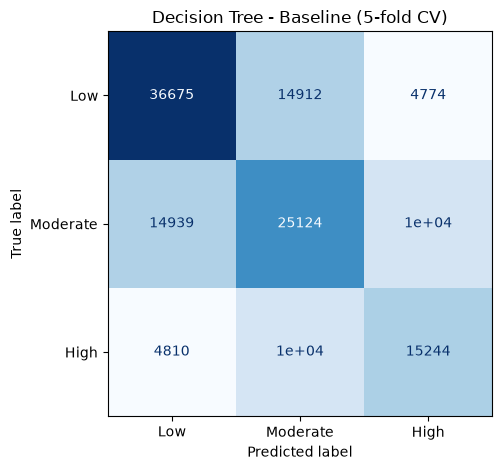

In [4]:
y_pred = cross_val_predict(baseline_model, X_train, y_train, cv=cv, n_jobs=-1)

# How many of the real High Risk cases (label 2) the model found
high_risk_recall = recall_score(y_train, y_pred, labels=[2], average="macro")
print(f"High Risk recall: {high_risk_recall:.3f}")

ConfusionMatrixDisplay.from_predictions(y_train, y_pred, display_labels=["Low", "Moderate", "High"],
                                        cmap="Blues", colorbar=False)
plt.title("Decision Tree - Baseline (5-fold CV)")
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning (Stage 7)
**Search strategy: GridSearchCV.** It tries **every combination** of the settings below with the same 5-fold CV
and keeps the one with the best Macro F1. The grid was **extended** after the first run, because the best value
(`max_depth=20`) was at the edge of the old grid.

| Setting | Values tried | What it controls |
|---|---|---|
| `max_depth` | 10, 15, 20, 25, 30, None | How many levels of questions the tree can ask. Limits overfitting |
| `min_samples_leaf` | 10, 20, 50 | Minimum records in a final leaf. Stops rules that are based on only a few records |

In [5]:
param_grid = {"max_depth": [10, 15, 20, 25, 30, None], "min_samples_leaf": [10, 20, 50]}

start = time.time()
search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
search.fit(X_train, y_train)

print("Best settings:", search.best_params_)
print(f"Best Macro F1: {search.best_score_:.4f}  ({time.time() - start:.0f}s)")

Best settings: {'max_depth': 25, 'min_samples_leaf': 20}
Best Macro F1: 0.5860  (22s)


In [6]:
# Is the best value inside the grid, or on the edge? (an edge value means the grid may be too small)
for name, values in param_grid.items():
    best_val = search.best_params_[name]
    nums = [v for v in values if isinstance(v, (int, float)) and not isinstance(v, bool)]
    if best_val is None:
        print(f"{name} = None (no limit) -> this is the END of the grid")
    elif len(nums) >= 3 and best_val in (min(nums), max(nums)):
        print(f"{name} = {best_val} is on the EDGE of the grid {values} -> extend the grid")
    else:
        print(f"{name} = {best_val} is INSIDE the grid {values} -> grid is wide enough")

max_depth = 25 is INSIDE the grid [10, 15, 20, 25, 30, None] -> grid is wide enough
min_samples_leaf = 20 is INSIDE the grid [10, 20, 50] -> grid is wide enough


In [7]:
# Score of every combination that was tried, best first
grid_results = pd.DataFrame(search.cv_results_)[["params", "mean_test_score", "std_test_score"]]
grid_results.columns = ["Settings", "Macro F1", "Std"]
grid_results.sort_values("Macro F1", ascending=False).round(4)

,Settings,Macro F1,Std
10,"{'max_depth': 25, 'min_samples_leaf': 20}",0.5860,0.0016
16,"{'max_depth': None, 'min_samples_leaf': 20}",0.5856,0.0015
13,"{'max_depth': 30, 'min_samples_leaf': 20}",0.5854,0.0014
7,"{'max_depth': 20, 'min_samples_leaf': 20}",0.5848,0.0021
14,"{'max_depth': 30, 'min_samples_leaf': 50}",0.5838,0.0023
17,"{'max_depth': None, 'min_samples_leaf': 50}",0.5838,0.0023
11,"{'max_depth': 25, 'min_samples_leaf': 50}",0.5836,0.0023
8,"{'max_depth': 20, 'min_samples_leaf': 50}",0.5824,0.0020
6,"{'max_depth': 20, 'min_samples_leaf': 10}",0.5819,0.0020
9,"{'max_depth': 25, 'min_samples_leaf': 10}",0.5802,0.0017


## 7. Baseline vs Tuned

Baseline F1    0.5511
Tuned F1       0.5860
dtype: float64
Improvement: +0.0350


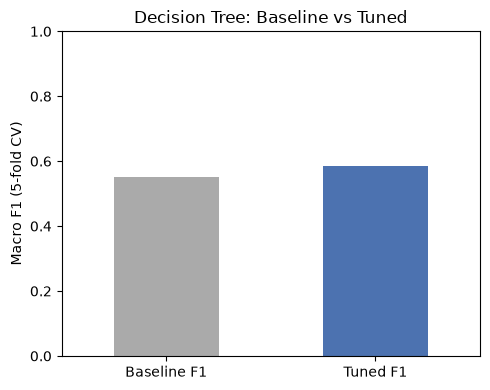

In [8]:
compare = pd.Series({
    "Baseline F1": baseline["F1 (macro)"],
    "Tuned F1": search.best_score_,
})
print(compare.round(4))
print(f"Improvement: {compare['Tuned F1'] - compare['Baseline F1']:+.4f}")

compare.plot(kind="bar", color=["#AAAAAA", "#4C72B0"], rot=0, figsize=(5, 4))
plt.title("Decision Tree: Baseline vs Tuned")
plt.ylabel("Macro F1 (5-fold CV)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [9]:
MODEL_TITLE = "Decision Tree"      # <- change in each notebook

# Full evaluation of the TUNED model (same folds, same metrics as the baseline)
tuned_model = search.best_estimator_

start = time.time()
t_scores = cross_validate(tuned_model, X_train, y_train, cv=cv, scoring=scoring,
                          return_train_score=True, n_jobs=-1)
tuned_cv_time = time.time() - start

tuned = {
    "Accuracy": t_scores["test_accuracy"].mean(),
    "Precision": t_scores["test_precision"].mean(),
    "Recall": t_scores["test_recall"].mean(),
    "F1 (macro)": t_scores["test_f1"].mean(),
    "F1 std": t_scores["test_f1"].std(),
    "Train F1": t_scores["train_f1"].mean(),
    "CV time (s)": tuned_cv_time,
}

y_pred_t = cross_val_predict(tuned_model, X_train, y_train, cv=cv, n_jobs=-1)
tuned["High Risk Recall"] = recall_score(y_train, y_pred_t, labels=[2], average="macro")

# Baseline and tuned side by side
side = pd.DataFrame({"Baseline": baseline, "Tuned": tuned})
side.loc["High Risk Recall", "Baseline"] = high_risk_recall
side.round(4)

,Baseline,Tuned
Accuracy,0.5624,0.6028
Precision,0.5511,0.5950
Recall,0.5511,0.5813
F1 (macro),0.5511,0.5860
F1 std,0.0037,0.0016
Train F1,0.9988,0.6575
CV time (s),7.6950,2.3705
High Risk Recall,0.5032,0.4753


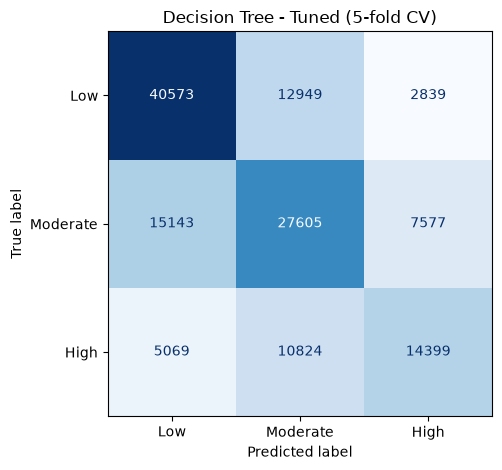

In [10]:
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_t, display_labels=["Low", "Moderate", "High"],
                                        cmap="Blues", colorbar=False)
plt.title(f"{MODEL_TITLE} - Tuned (5-fold CV)")
plt.tight_layout()
plt.show()

## 8. Observations
**Results**

| | Macro F1 | Accuracy | Train F1 | High Risk Recall |
|---|---|---|---|---|
| Baseline (no limits) | 0.551 | 0.562 | 0.999 | 0.503 |
| Tuned (`max_depth=25`, `min_samples_leaf=20`) | **0.586** | 0.603 | 0.658 | 0.475 |

- **The baseline tree overfits badly.** It scores 0.999 on the training data but only 0.551 on validation data. It has memorised the training records instead of learning general rules.
- **Tuning gave the biggest improvement of all four models (+0.035).** Requiring at least 20 records per leaf forces the tree to learn rules that hold for many records. Train F1 dropped from 0.999 to 0.658, so the gap between train and validation is much smaller (0.658 vs 0.586).
- **Grid check:** the grid was extended to `max_depth` 30 and None. The best value (25) is now inside the grid. Depth 25, 30 and None all score about 0.585 to 0.586 (std 0.0016), so the score has levelled off and a bigger grid is not needed. `min_samples_leaf=20` beat both 10 and 50.
- **Trade-off:** tuning raised accuracy (0.562 to 0.603), precision (0.551 to 0.595) and Macro F1, but **High Risk recall went down** (0.503 to 0.475). The smoother tree predicts High Risk less often, so it misses more real High Risk records.
- **Why it beats Logistic Regression:** a tree can learn feature combinations (carrier + airport + season), which is how delay risk actually works.
- **Why it is behind Random Forest:** a single tree is unstable. A small change in the data can change the whole tree. Random Forest fixes this by averaging many trees.

## 9. Save the Results
These results are loaded by `Final_Model_Comparison.ipynb` to compare all four models.

In [11]:
import os
os.makedirs("results", exist_ok=True)

MODEL_NAME = "Decision Tree"
FILE_NAME = "decision_tree"

result_row = {
    "Model": MODEL_NAME,
    **{f"Baseline {k}": v for k, v in baseline.items()},
    "Baseline High Risk Recall": high_risk_recall,
    "Tuned F1": search.best_score_,
    **{f"Tuned {k}": v for k, v in tuned.items() if k != "F1 (macro)"},
    "Best Params": json.dumps(search.best_params_),   # the final notebook rebuilds the model from these
}
pd.DataFrame([result_row]).to_csv(f"results/{FILE_NAME}_results.csv", index=False)

# Full record of every combination that was tried (experiment log)
pd.DataFrame(search.cv_results_).sort_values("rank_test_score").to_csv(f"results/{FILE_NAME}_grid.csv", index=False)
print(f"Saved results/{FILE_NAME}_results.csv and results/{FILE_NAME}_grid.csv")

Saved results/decision_tree_results.csv and results/decision_tree_grid.csv
